In [1]:
import json
import os
import clip
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from ollama import Client

from utils import dataset_utils
from datasets.mvtec_dataset import MVTecDataset
from datasets.realiad_dataset import RealIadDataset
from moviad.utilities.configurations import TaskType, LabelName

In [2]:
client = Client(host="http://localhost:6000")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
MODEL_NAME = "gemma3:12b"
categories = ["grid"]
dataset_path_mvtec = "/mnt/disk1/borsattifr/datasets/mvtec"
dataset_path_realiad = "/mnt/disk1/yfbenkhalifa/datasets/realiad/realiad_256"

## Create concept list

In [3]:
def create_concept_list(dataset_path, dataset_type, categories):

    for category in categories:

        concepts = set()

        if dataset_type == "mvtec":
            train_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "train")
            train_dataset.load_dataset()

            test_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "test")
            test_dataset.load_dataset()

            dataset = pd.concat([train_dataset.samples, test_dataset.samples])
        
        elif dataset_type == "realiad":
            dataset = RealIadDataset(root = dataset_path, category=category)
            dataset.load_dataset()

        subset = dataset.samples.groupby("label", group_keys=False).sample(frac = 0.05, random_state = 42)
        print(f"Number of images to analyze: {len(subset)}")

        for i in range(len(subset)):
            sample = subset.iloc[i]
            concept_json = dataset_utils.first_vlm_query(category, MODEL_NAME, sample)
            concepts.update(c.lower() for c in concept_json)

        concepts = list(concepts)
        
        output_dir = f"concept_lists/original/{dataset_type}"
        os.makedirs(output_dir, exist_ok=True)

        with open(os.path.join(output_dir, f"{category}_concepts.json"), "w") as f:
            json.dump(concepts, f)

In [24]:
categories = ["zipper"]

create_concept_list(dataset_path=dataset_path_realiad, dataset_type = "realiad", categories = categories)

Number of images to analyze: 251



## Inspect list

In [4]:
def number_of_concepts(category, dataset_type):
    path = f"concept_lists/original/{dataset_type}/{category}_concepts.json"
    with open(path, "r") as f:
        concepts = json.load(f)
    print(f"Original number of concepts for {category}:", len(concepts))
    return concepts

In [ ]:
original_hazelnut_concepts = number_of_concepts("hazelnut", "mvtec")
original_carpet_concepts = number_of_concepts("carpet", "mvtec")
original_screw_concepts = number_of_concepts("screw", "mvtec")
original_grid_concepts = number_of_concepts("grid", "mvtec")


Original number of concepts for hazelnut: 149
Original number of concepts for carpet: 161
Original number of concepts for screw: 229
Original number of concepts for grid: 223


In [5]:
original_mint_concepts = number_of_concepts("mint", "realiad")
original_zipper_concepts = number_of_concepts("zipper", "realiad")

Original number of concepts for mint: 203
Original number of concepts for zipper: 250


### First step: query an LLM to aggregate logically similar concepts

In [6]:
def filter_concepts(concepts, category, dataset_type):

    message = "You are an industrial expert that is performing the task of visual anomaly detection."\
            f"Given the following list of visual concepts: {concepts}, related to images of a {category}, please group together those that refer to the same LITERAL meaning, i.e. if they share key words, spelling..."\
            "Ignore semantic relationships, focus only on literal wording and string similarity."\
            "Moreover, choose a representative attribute that best summarizes the group."\
            "I provide two examples: 1. 'Elliptical shape': ['ellipsoidal shape', 'ellipsoid shape', 'elliptical shape']"\
            "2. 'Smooth texture': ['natural texture, 'smooth texture', 'smooth surface texture', 'smooth appearance', 'organic texture', 'uniform texture', 'consistent texture']"\
            "DO NOT create groups that are too general, e.g. grouping together all colours or all textures. Representative concepts should still be able to clearly discriminate between normal and anomalous images."\
            "Return the output as a JSON dictionary where each key is the representative concept, and its value is the list of similar concepts grouped with it."\
            "In case of concepts that cannot be grouped with any other concept, the dictionary should have both as key and value the concept itself."\
            "Please, output ONLY the JSON dictionary."

    response = client.chat(model=MODEL_NAME, messages=[{"role": "user", "content": message}])

    try:
        concept_json = dataset_utils.extract_json(response["message"]["content"])
    except Exception as e:
        print(f"Error parsing response: {e}")
        concept_json = []
    
    print(f"Number of concepts extracted by the LLM for {category}:", len(concept_json))
    print(f"Extracted concepts for {category}:", concept_json.keys())

    with open(f"concept_lists/filtered/{dataset_type}/{category}_concepts.json", "w") as f:
        json.dump(concept_json, f)

In [7]:
filter_concepts(original_zipper_concepts, "zipper", "realiad")

Number of concepts extracted by the LLM for zipper: 59
Extracted concepts for zipper: dict_keys(['broken zipper', 'interlocked teeth', 'irregular slider position', 'foreign material', 'compressed area', 'bent teeth', 'disrupted alignment', 'gaps in structure', 'irregular staining', 'smooth texture', 'deformed fabric', 'corrosion present', 'rectangular shape', 'parallel elements', 'distorted pattern', 'deposit', 'reduced density', 'linear pattern', 'irregular texture', 'dark spots', 'fabric tear', 'missing tooth', 'chain separation', 'elongated shape', 'parallel ribs', 'distorted shape', 'twisted profile', 'incomplete row', 'distorted closure', 'deformed pull tab', 'visible tearing', 'debris accumulation', 'frayed edge', 'tooth profile', 'surface irregularity', 'wavy profile', 'surface fracture', 'material adhesion', 'adherent substance', 'missing component', 'surface residue', 'deformed zipper slider', 'damaged slider', 'bent slider', 'shifted position', 'metallic teeth', 'visible teet

### Second step: filter concept list

In [8]:
def load_concepts(category, dataset_type):
    with open(f"concept_lists/filtered/{dataset_type}/{category}_concepts.json", "r") as f:
        filtered_concepts = json.load(f)

    final_concepts = list(filtered_concepts.keys())

    return final_concepts

In [9]:
final_zipper_concepts = load_concepts("zipper", "realiad")

In [10]:
#remove concepts with high cosine similarity
def compute_concept_similarity(model, concepts, threshold = 0.9):
    model.eval()
    model.to("cpu")
    with torch.no_grad():
        text_tokens = clip.tokenize(concepts).to("cpu")
        text_features = model.encode_text(text_tokens)
    
        #normalize features
        text_features /= text_features.norm(dim = -1, keepdim = True)

    #compute cosine similarity between pairs
    similarities = (text_features @ text_features.T).cpu().numpy()
    np.fill_diagonal(similarities, 0.0) #ignore self-similarity

    high_sim_counts = (similarities > threshold).sum(axis = 1)

    print("\nHigh similarity pairs (> 0.9):")
    for i in range(len(concepts)):
        for j in range(i + 1, len(concepts)):
            sim = similarities[i, j]
            if sim > threshold:
                print(f"{concepts[i]} ↔ {concepts[j]}: {sim:.4f}")

    #remove concepts with more than two high-similarity matches
    concepts_to_remove = set(np.array(concepts)[high_sim_counts >= 2])

    #for remaining pairs, remove one of each
    remaining_idx = [i for i, c in enumerate(concepts) if c not in concepts_to_remove]
    remaining_concepts = [concepts[i] for i in remaining_idx]
    remaining_similarities = similarities[np.ix_(remaining_idx, remaining_idx)]

    #track which indices to drop
    already_removed = set()
    for i in range(len(remaining_idx)):
        for j in range(i + 1, len(remaining_idx)):
            if remaining_similarities[i, j] > threshold:
                if remaining_concepts[i] not in already_removed and remaining_concepts[j] not in already_removed:
                    already_removed.add(remaining_concepts[i])
    
    all_removed = concepts_to_remove.union(already_removed)

    final_concepts = [c for c in remaining_concepts if c not in already_removed]
    print("Concepts removed:", all_removed)
    print("Number of concepts kept:", len(final_concepts))

    return final_concepts

In [11]:
model, preprocess = clip.load("ViT-B/32", jit = False)

final_zipper_concepts = compute_concept_similarity(model, final_zipper_concepts)


High similarity pairs (> 0.9):
broken zipper ↔ deformed zipper slider: 0.9170
interlocked teeth ↔ bent teeth: 0.9180
interlocked teeth ↔ visible teeth: 0.9116
irregular slider position ↔ damaged slider: 0.9019
irregular slider position ↔ missing slider: 0.9019
irregular slider position ↔ broken slider: 0.9409
irregular slider position ↔ shifted slider: 0.9253
bent teeth ↔ visible teeth: 0.9126
disrupted alignment ↔ parallel alignment: 0.9180
smooth texture ↔ irregular texture: 0.9146
deformed fabric ↔ fabric tear: 0.9097
parallel elements ↔ parallel alignment: 0.9194
distorted pattern ↔ linear pattern: 0.9175
distorted pattern ↔ distorted shape: 0.9360
irregular texture ↔ surface irregularity: 0.9219
irregular texture ↔ surface fracture: 0.9028
irregular texture ↔ surface residue: 0.9028
missing tooth ↔ visible teeth: 0.9121
distorted shape ↔ twisted profile: 0.9082
distorted shape ↔ distorted closure: 0.9229
twisted profile ↔ distorted profile: 0.9136
surface irregularity ↔ surface f

In [12]:
## remove concepts that have a high cosine similarity with the class ("anomalous") or the category
def compute_class_similarity(model, concepts, category, classes = ["anomalous", "normal"], threshold = 0.9):
    references = [category] + classes

    with torch.no_grad():
        ref_tokens = clip.tokenize(references).to("cpu")
        ref_features = model.encode_text(ref_tokens)
        ref_features = ref_features / ref_features.norm(dim = -1, keepdim = True)

        text_tokens = clip.tokenize(concepts).to("cpu")
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim = -1, keepdim = True)
    
    similarities = (text_features @ ref_features.T).cpu().numpy()

    concepts_to_remove = set()
    for i, concept in enumerate(concepts):
        for j, ref in enumerate(references):
            sim = similarities[i, j]
            if sim > threshold:
                concepts_to_remove.add(concept)
                print(f"{concept} — high similarity to '{ref}': {sim:.4f}")
                break  
    
    final_concepts = [c for c in concepts if c not in concepts_to_remove]
    print("Number of concepts kept:", len(final_concepts))
    return final_concepts

In [13]:
final_zipper_concepts = compute_class_similarity(model, final_zipper_concepts, "zipper")

Number of concepts kept: 40


In [14]:
with open(f"concept_lists/filtered/realiad/zipper_concepts.json", "w") as f:
        json.dump(final_zipper_concepts, f)


## Final Dataset creation

### 1st strategy: VLM prompting

In [3]:
with open(f"concept_lists/filtered/realiad/zipper_concepts.json", "r") as f:
    final_zipper_concepts = json.load(f)

In [4]:
from tqdm import tqdm

def create_final_dataset(dataset_path, dataset_type, category, final_concepts):
    image_concepts = []

    if dataset_type == "mvtec":
        train_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "train")
        train_dataset.load_dataset()

        test_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "test")
        test_dataset.load_dataset()

        samples = pd.concat([train_dataset.samples, test_dataset.samples])
    
    elif dataset_type == "realiad":
        dataset = RealIadDataset(root = dataset_path, category=category)
        dataset.load_dataset()
        samples = dataset.samples

    for i in tqdm(range(len(samples))):
        sample = samples.iloc[i]
        concept_vector = dataset_utils.second_vlm_query(category, MODEL_NAME, sample, final_concepts)
        image_concepts.append(concept_vector)

    concepts_df = pd.DataFrame(image_concepts, columns = [f"{c}" for c in final_concepts])
    final_df = pd.concat([samples.reset_index(drop=True), concepts_df], axis=1)

    save_path = f"/mnt/disk1/arianna_stropeni/cbm_data/{dataset_type}/{category}_dataset_automated.csv"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    final_df.to_csv(save_path, index = False)
    return final_df

In [5]:
zipper_df = create_final_dataset(dataset_path = dataset_path_realiad, dataset_type = "realiad", category = "zipper", final_concepts = final_zipper_concepts)

100%|██████████| 5005/5005 [7:52:36<00:00,  5.67s/it]  


### 2nd Strategy: CLIP

In [44]:
model, preprocess = clip.load("ViT-B/32", jit = False)

In [45]:
### function to use CLIP on an image
def extract_concepts_with_clip(model, preprocess, df, concepts, category, threshold = 0.2):
    model.eval()
    model.to("cpu")
    text_inputs = torch.cat([clip.tokenize(f"a {category} with a {c}") for c in concepts]).to("cpu")

    concept_rows = []

    for i, row in df.iterrows():
        image_path = row["image_path"]
        image = Image.open(image_path).convert("RGB")
        image_input = preprocess(image).unsqueeze(0).to("cpu")
        #calculate features
        with torch.no_grad():
            image_features = model.encode_image(image_input)
            text_features = model.encode_text(text_inputs)
    
        #normalize features
        image_features /= image_features.norm(dim = -1, keepdim = True)
        text_features /= text_features.norm(dim = -1, keepdim = True)

        #compute similarity between image and text features
        similarities = (100.0 * image_features @ text_features.T).softmax(dim = -1)
        probabilities = similarities[0].tolist()

        concept_presence = {concept: int(prob > threshold) for concept, prob in zip(concepts, probabilities)}
        concept_rows.append(concept_presence)
    
    concept_df = pd.DataFrame(concept_rows)
    
    for col in concept_df.columns:
        df[col] = concept_df[col]
    
    df.to_csv(f"/mnt/disk1/arianna_stropeni/cbm_data/mvtec/{category}_dataset_clip.csv", index = False)

In [46]:
path_hazelnut = "/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset.csv"
hazelnut_df = pd.read_csv(path_hazelnut)

final_hazelnut_concepts = [col for col in hazelnut_df.columns if col not in ["split", "anomaly_type", "image_path", "label_index", "mask_path"]]

extract_concepts_with_clip(model, preprocess, hazelnut_df, final_hazelnut_concepts, category = "hazelnut")


### Split the dataset

In [6]:
def read_csv(path):
    final_df = pd.read_csv(path)
    return final_df

In [7]:
zipper_df = read_csv('/mnt/disk1/arianna_stropeni/cbm_data/realiad/zipper_dataset_automated.csv')

In [8]:
def adjust_columns(df):
    #define the anomaly type
    if "label" in df.columns:
        df = df.rename(columns={"label": "anomaly_type"})

    #drop unnecessary columns
    if "split" in df.columns and "path" in df.columns:
        df = df.drop(columns = ["path", "split"])

    return df

In [9]:
zipper_df = adjust_columns(zipper_df)

In [10]:
def split_dataframe(df, train_size = 0.8, test_size = 0.5):   
    train_df, val_test_df = train_test_split(df, train_size = train_size, stratify=df["anomaly_type"], shuffle = True)

    val_df, test_df = train_test_split(val_test_df, test_size=test_size, shuffle = True)

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"

    df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

    summary = df.groupby(["anomaly_type", "split"]).size().unstack(fill_value=0)
    print(summary)

    return df

In [11]:
zipper_df = split_dataframe(zipper_df)

split          test  train  val
anomaly_type                   
contamination    67    508   60
damage           48    409   54
deformation      58    448   54
good            267   2139  268
missing parts    61    500   64


In [12]:
zipper_df.to_csv('/mnt/disk1/arianna_stropeni/cbm_data/realiad/zipper_dataset_automated.csv', index = False)

### Remove uninformative concepts

In [13]:
with open(f"concept_lists/filtered/realiad/zipper_concepts.json", "r") as f:
    final_zipper_concepts = json.load(f)

In [14]:
def drop_concepts(df, concepts, num_images):
    existing_concepts = [col for col in concepts if col in df.columns]
    #drop concepts that appear in less than 10 images
    invalid_concepts = df[existing_concepts].sum()[lambda x: x < 10].index
    print("Concepts that appear in less than 10 images:", invalid_concepts)

    df = df.drop(columns=invalid_concepts)

    remaining_concepts = [col for col in existing_concepts if col not in invalid_concepts]
    #drop concepts that appear in more than 95% of the images
    always_present_concepts = df[remaining_concepts].sum()[lambda x: x > num_images * 0.95].index
    print("Concepts that appear in more than 95% of images:", always_present_concepts)

    df = df.drop(columns=always_present_concepts)

    remained_concepts = [col for col in concepts if col in df.columns]

    return df, remained_concepts

In [15]:
zipper_df, remained_zipper_concepts = drop_concepts(zipper_df, final_zipper_concepts, num_images=len(zipper_df))

Concepts that appear in less than 10 images: Index(['compressed area', 'corrosion present', 'reduced density',
       'fabric tear', 'deformed pull tab', 'visible tearing', 'frayed edge',
       'abrasions'],
      dtype='object')
Concepts that appear in more than 95% of images: Index(['parallel elements', 'linear pattern', 'tooth profile',
       'metallic teeth'],
      dtype='object')


In [16]:
zipper_df.to_csv('/mnt/disk1/arianna_stropeni/cbm_data/realiad/zipper_dataset_automated.csv', index = False)

### Remove highly correlated concepts

In [17]:
def compute_correlation(df, concepts, threshold = 0.95):
    concepts_to_use = [col for col in concepts if col in df.columns]
    correlation_matrix = df[concepts_to_use].corr().abs()

    plt.figure(figsize=(18, 15))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
    plt.show()

    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] >= threshold)]

    print(f"Concepts with correlation >= {threshold}: {to_drop}")

    df = df.drop(columns = to_drop)

    return df

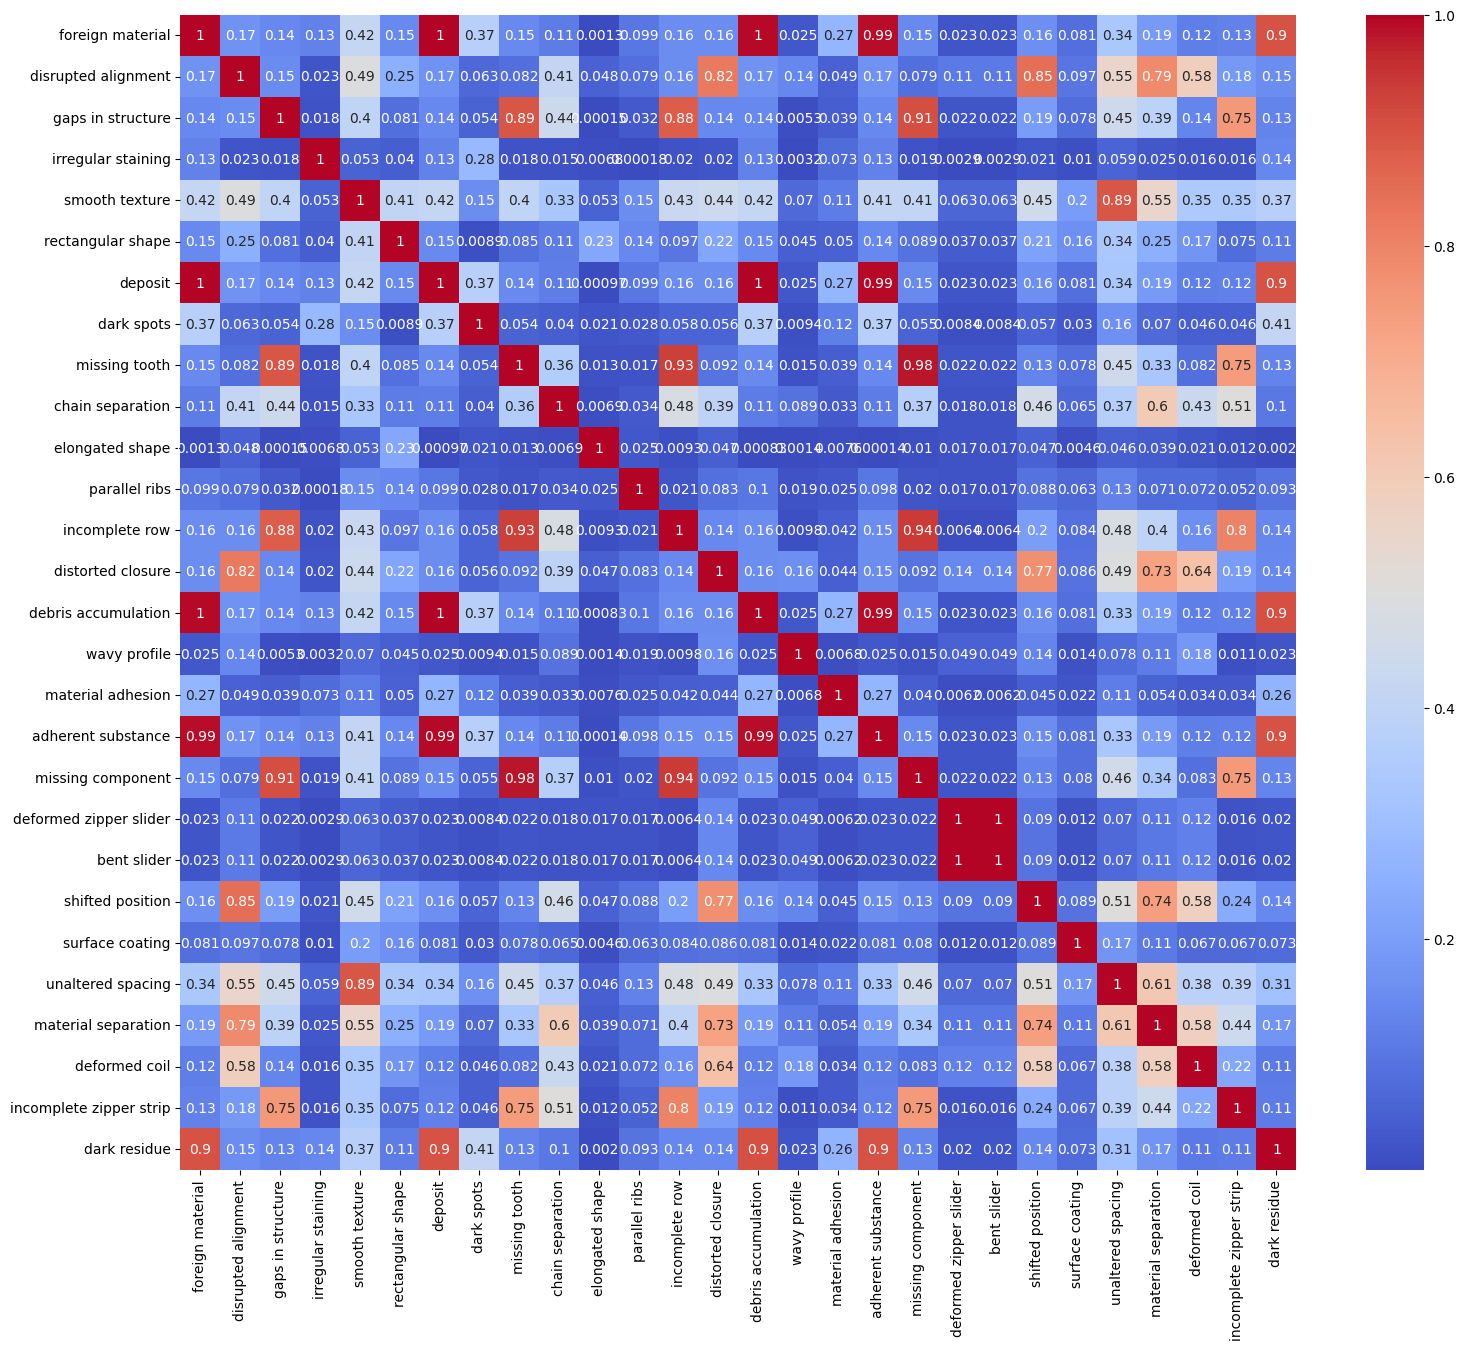

Concepts with correlation >= 0.95: ['deposit', 'debris accumulation', 'adherent substance', 'missing component', 'bent slider']


In [18]:
zipper_df = compute_correlation(zipper_df, remained_zipper_concepts)

In [19]:
zipper_df.to_csv(f"/mnt/disk1/arianna_stropeni/cbm_data/realiad/zipper_dataset_automated.csv", index = False)
final_zipper_concepts = [col for col in final_zipper_concepts if col in zipper_df.columns]
print("Number of final concepts:", len(final_zipper_concepts))

Number of final concepts: 23


## (Optional) Manually check concept annotation

In [100]:
final_carpet_concepts

['Hole',
 'Dark Area',
 'Color Variation',
 'Fiber Protrusion',
 'Metallic Sheen',
 'Uneven Distribution',
 'Lighter Area',
 'Irregular Shape',
 'Unraveling',
 'Texture Disruption',
 'Chromatic Anomaly',
 'Shadowed Area',
 'Spotty Appearance',
 'Rectangular Pattern',
 'Detached Fiber',
 'Damaged Fiber',
 'Neutral Color',
 'Isolated Patch',
 'Discoloration',
 'Pattern Disruption',
 'Short Fibers']

In [106]:
#automatically exclude anomalous concepts
anomalous_concepts = ['Dark Area', 'Uneven Distribution', 'Color Variation', 'Fiber Protrusion', 'Hole', 'Metallic Sheen', 'Unraveling', 'Texture Disruption', 'Chromatic Anomaly', 'Pattern Disruption', 'Detached Fiber', 'Damaged Fiber']

carpet_df.loc[carpet_df["label_index"] == 0, anomalous_concepts] = 0

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image as PILImage
import ipywidgets as widgets
import os


# --- Define editable features ---
editable_columns = [col for col in carpet_df.columns if col not in ["image_path", "split", "label", "mask_path", "path"]]


def show_image(index):
    print(f"Rendering index {index}")
    row = carpet_df.iloc[index]

    img = PILImage.open(row["image_path"])
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {row['label_index']}")
    plt.show()

    # Create input widgets for each editable feature
    editors = {}
    for col in editable_columns:
        value = row[col]
        if isinstance(value, (int, float)):
            editor = widgets.FloatText(value=value, description=col)
        else:
            editor = widgets.Text(value=str(value), description=col)
        editors[col] = editor

    # Button to save edits
    save_button = widgets.Button(description="Save Changes", button_style='success')

    def save_changes(b):
        for col, widget in editors.items():
            carpet_df.at[index, col] = widget.value
        print(f"✅ Changes saved for index {index}")

    save_button.on_click(save_changes)

    # Display form
    display(widgets.VBox(list(editors.values()) + [save_button]))


# Interface to scroll through samples
widgets.interact(show_image, index=widgets.IntSlider(min=0, max=len(carpet_df)-1, step=1))

interactive(children=(IntSlider(value=0, description='index', max=396), Output()), _dom_classes=('widget-inter…

<function __main__.show_image(index)>

In [109]:
carpet_df.to_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv", index = False)

## (Done) Create complete dataset

In [ ]:
#mvtec dataset
categories = ["bottle", "cable", "capsule", "carpet", "grid", "hazelnut", "leather", "metal_nut", "pill", "screw", "tile", "toothbrush", "transistor", "wood", "zipper"]
full_dataset_mvtec = pd.DataFrame()

for category in categories:
    for split in ["train", "test"]:
        partial_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path_mvtec, category = category, split = split)
        partial_dataset.load_dataset()
        partial_dataset.samples["category"] = category

        full_dataset_mvtec = pd.concat([full_dataset_mvtec, partial_dataset.samples], ignore_index=True)

full_dataset_mvtec = full_dataset_mvtec.reset_index(drop=True)

In [6]:
#real-iad dataset
categories = ["switch", "u_block", "usb", "woodstick", "rolled_strip_base", "toy", "eraser", "usb_adaptor", "fire_hood", "regulator", "porcelain_doll", "toothbrush", "wooden_beads", "button_battery", "mounts",
              "plastic_nut", "pcb", "end_cap", "phone_battery", "bottle_cap", "mint", "toy_brick", "plastic_plug", "zipper", "audiojack", "terminalblock", "tape", "transistor1", "sim_card_set", "vcpill"]
full_dataset_realiad = pd.DataFrame()

for category in categories:
    partial_dataset = RealIadDataset(root = dataset_path_realiad, category=category)
    print(f"Loading {category} dataset...")
    partial_dataset.load_dataset()
    partial_dataset.samples["category"] = category
    full_dataset_realiad = pd.concat([full_dataset_realiad, partial_dataset.samples], ignore_index=True)

full_dataset_realiad = full_dataset_realiad.reset_index(drop=True)

Loading switch dataset...


Loading u_block dataset...
Loading usb dataset...
Loading woodstick dataset...
Loading rolled_strip_base dataset...
Loading toy dataset...
Loading eraser dataset...
Loading usb_adaptor dataset...
Loading fire_hood dataset...
Loading regulator dataset...
Loading porcelain_doll dataset...
Loading toothbrush dataset...
Loading wooden_beads dataset...
Loading button_battery dataset...
Loading mounts dataset...
Loading plastic_nut dataset...
Loading pcb dataset...
Loading end_cap dataset...
Loading phone_battery dataset...
Loading bottle_cap dataset...
Loading mint dataset...
Loading toy_brick dataset...
Loading plastic_plug dataset...
Loading zipper dataset...
Loading audiojack dataset...
Loading terminalblock dataset...
Loading tape dataset...
Loading transistor1 dataset...
Loading sim_card_set dataset...
Loading vcpill dataset...


In [8]:
full_dataset_realiad["stratify_key"] = full_dataset_realiad["category"].astype(str) + "_" + full_dataset_realiad["label_index"].astype(str)

In [9]:
from sklearn.model_selection import train_test_split

train_df, val_test_df = train_test_split(full_dataset_realiad, test_size=0.1, stratify=full_dataset_realiad["stratify_key"], shuffle = True)

val_df, test_df = train_test_split(val_test_df, test_size=0.5, stratify = val_test_df["stratify_key"], shuffle = True)

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

full_dataset_realiad = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

In [18]:
full_dataset_realiad['category_index'] = full_dataset_realiad['category'].astype('category').cat.codes

In [20]:
full_dataset_realiad.to_csv("/mnt/disk1/arianna_stropeni/cbm_data/realiad/full_dataset.csv", index = False)

In [19]:
full_dataset_realiad

,image_path,anomaly_type,label_index,mask_path,category,split,category_index
0,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,phone_battery,train,9
1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,pit,1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,mounts,train,7
2,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,mounts,train,7
3,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,terminalblock,train,18
4,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,contamination,1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,end_cap,train,3
...,...,...,...,...,...,...,...
151045,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,zipper,test,29
151046,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,pit,1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,plastic_plug,test,11
151047,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,sim_card_set,test,15
151048,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,audiojack,test,0


## Analysis of concepts

In [8]:
screw_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/screw_dataset_automated.csv")
screw_concepts = [col for col in screw_df.columns if col not in ["image_path", "mask_path", "label_index", "anomaly_type", "split"]]

### Discriminative analysis


In [9]:
#chi square test
def chi_square_test(df, concepts):
    for col in concepts:
        contingency = pd.crosstab(df[col], df["label_index"])
        chi2, p, dof, ex = chi2_contingency(contingency)
        print(f"{col}: p-value = {p:.2e}")
        prob_anomalous = df[df["label_index"] == 1][col].mean()
        prob_normal = df[df["label_index"] == 0][col].mean()
        print(f"{col}: P(concept=1 | anomaly) = {prob_anomalous:.2f}, P(concept=1 | normal) = {prob_normal:.2f}")

In [10]:
chi_square_test(screw_df, screw_concepts)

Head scratch: p-value = 8.43e-57
Head scratch: P(concept=1 | anomaly) = 0.61, P(concept=1 | normal) = 0.00
Neck scratch: p-value = 1.93e-44
Neck scratch: P(concept=1 | anomaly) = 0.49, P(concept=1 | normal) = 0.00
thread truncation: p-value = 3.22e-40
thread truncation: P(concept=1 | anomaly) = 0.45, P(concept=1 | normal) = 0.00
metal abrasion: p-value = 2.48e-38
metal abrasion: P(concept=1 | anomaly) = 0.66, P(concept=1 | normal) = 0.08
head marking: p-value = 3.01e-06
head marking: P(concept=1 | anomaly) = 0.13, P(concept=1 | normal) = 0.37
altered geometry: p-value = 4.41e-54
altered geometry: P(concept=1 | anomaly) = 0.58, P(concept=1 | normal) = 0.00
tapered form: p-value = 1.52e-68
tapered form: P(concept=1 | anomaly) = 0.12, P(concept=1 | normal) = 0.94
Flat head: p-value = 2.01e-04
Flat head: P(concept=1 | anomaly) = 0.01, P(concept=1 | normal) = 0.13
visible_markings: p-value = 3.52e-20
visible_markings: P(concept=1 | anomaly) = 0.88, P(concept=1 | normal) = 0.39
uniform appea

### Check differences between fully automated dataset and partially automated dataset

In [47]:
hazelnut_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset.csv")
hazelnut_df_automated = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset_automated.csv")
hazelnut_df_clip = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset_clip.csv")

In [48]:
final_hazelnut_concepts = [col for col in hazelnut_df.columns if col not in ["split", "anomaly_type", "image_path", "label_index", "mask_path"]]

In [57]:
carpet_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv")
carpet_df_automated = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset_automated.csv")

In [61]:
cropped_carpet_df = carpet_df.iloc[:60]
cropped_carpet_df_automated = carpet_df_automated[carpet_df_automated["image_path"].isin(cropped_carpet_df["image_path"])]

In [68]:
final_carpet_concepts = [col for col in cropped_carpet_df.columns if col  not in ["Unnamed: 0", "split", "anomaly_type", "image_path", "label_index", "mask_path"]]

In [49]:
indexed_manual = hazelnut_df.set_index("image_path")
indexed_automated = hazelnut_df_automated.set_index("image_path")
indexed_clip = hazelnut_df_clip.set_index("image_path")

In [30]:
def check_differences(df_1, df_2, column_name):
    merged_df = df_1[[column_name]].rename(columns={column_name: f"manual_{column_name}"}).join(df_2[[column_name]].rename(columns={column_name: f"automated_{column_name}"}), how = "inner")
    merged_df["differences"] = merged_df[f"manual_{column_name}"] != merged_df[f"automated_{column_name}"]

    #compute accuracy 
    accuracy = (merged_df[f'manual_{column_name}'] == merged_df[f"automated_{column_name}"]).mean()

    #compute precision and recall
    TP = ((merged_df[f'manual_{column_name}'] == 1) & (merged_df[f"automated_{column_name}"] == 1)).sum()
    TN = ((merged_df[f'manual_{column_name}'] == 0) & (merged_df[f"automated_{column_name}"] == 0)).sum()
    FP = ((merged_df[f'manual_{column_name}'] == 0) & (merged_df[f"automated_{column_name}"] == 1)).sum()
    FN = ((merged_df[f'manual_{column_name}'] == 1) & (merged_df[f"automated_{column_name}"] == 0)).sum()

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    # print(f"Accuracy of automated concepts for concept {column_name}: {accuracy:.2f}")
    # print(f"Precision of automated concepts for concept {column_name}: {precision:.2f}")
    # print(f"Recall of automated concepts for concept {column_name}: {recall:.2f}")

    return accuracy, precision, recall

In [40]:
def compute_avg_metrics(concepts, df_1, df_2, concept_type):
    all_acc = []
    all_prec = []
    all_rec = []

    for concept in concepts:
        accuracy, precision, recall = check_differences(df_1, df_2, concept)
        all_acc.append(accuracy)
        all_prec.append(precision)
        all_rec.append(recall)

    avg_acc, std_acc = np.mean(all_acc), np.std(all_acc)
    avg_prec, std_prec = np.mean(all_prec), np.std(all_prec)
    avg_rec, std_rec = np.mean(all_rec), np.std(all_rec)

    print(f"Average accuracy of {concept_type} concepts: {avg_acc:.2f} ± {std_acc:.2f}")
    print(f"Average precision of {concept_type} concepts: {avg_prec:.2f} ± {std_prec:.2f}")
    print(f"Average recall of {concept_type} concepts: {avg_rec:.2f} ± {std_rec:.2f}\n")

In [52]:
anomaly_concepts_obj = ["Crack", "Hole", "Split", "Fracture", "Visible Mark", "Visible Crevices", "Dark Interior", "Broken Shell", "Visible Ink"]
normal_concepts_obj = ["Intact Shell"]
anomaly_concepts_subj = ["Surface Imperfection", "Texture Anomaly", "Structural Damage", "Irregular Shape", "Surface Discontinuity", "Linear Disruption", "Uneven Tone", "Color Deviation"]
normal_concepts_subj = ["Compact Appearance", "Natural Appearance", "Uniform Appearance"]

In [ ]:
anomaly_concepts_obj = ["Hole", "Dark Area", "Metallic Sheen", "Lighter Area", "Shadowed Area", "Unraveling", "Chromatic Anomaly", "Isolated Patch"]
anomaly_concepts_subj = ["Color Variation", "Uneven Distribution", "Irregular Shape", "Spotty Appearance", "Discoloration", "Pattern Disruption"]
uniformative_concepts = ["Rectangular Pattern", "Neutral Color"]

In [42]:
#compute differences with gemma-annotated df
compute_avg_metrics(final_hazelnut_concepts, indexed_manual, indexed_automated, "all")
compute_avg_metrics(anomaly_concepts_obj, indexed_manual, indexed_automated, "objective anomaly-related")
compute_avg_metrics(normal_concepts_obj, indexed_manual, indexed_automated, "objective normality-related")
compute_avg_metrics(anomaly_concepts_subj, indexed_manual, indexed_automated, "subjective anomaly-related")
compute_avg_metrics(normal_concepts_subj, indexed_manual, indexed_automated, "subjective normality-related")

Average accuracy of all concepts: 0.93 ± 0.08
Average precision of all concepts: 0.76 ± 0.24
Average recall of all concepts: 0.77 ± 0.28

Average accuracy of objective anomaly-related concepts: 0.96 ± 0.03
Average precision of objective anomaly-related concepts: 0.71 ± 0.22
Average recall of objective anomaly-related concepts: 0.79 ± 0.25

Average accuracy of objective normality-related concepts: 0.99 ± 0.00
Average precision of objective normality-related concepts: 0.99 ± 0.00
Average recall of objective normality-related concepts: 1.00 ± 0.00

Average accuracy of subjective anomaly-related concepts: 0.87 ± 0.10
Average precision of subjective anomaly-related concepts: 0.71 ± 0.25
Average recall of subjective anomaly-related concepts: 0.63 ± 0.29

Average accuracy of subjective normality-related concepts: 0.98 ± 0.01
Average precision of subjective normality-related concepts: 0.99 ± 0.00
Average recall of subjective normality-related concepts: 0.99 ± 0.01



In [53]:
#compute differences with clip-annotated df
compute_avg_metrics(final_hazelnut_concepts, indexed_manual, indexed_clip, "all")
compute_avg_metrics(anomaly_concepts_obj, indexed_manual, indexed_clip, "objective anomaly-related")
compute_avg_metrics(anomaly_concepts_subj, indexed_manual, indexed_clip, "subjective anomaly-related")
compute_avg_metrics(normal_concepts_obj, indexed_manual, indexed_clip, "objective normality-related")
compute_avg_metrics(normal_concepts_subj, indexed_manual, indexed_clip, "subjective normality-related")

Average accuracy of all concepts: 0.70 ± 0.34
Average precision of all concepts: 0.05 ± 0.21
Average recall of all concepts: 0.05 ± 0.19

Average accuracy of objective anomaly-related concepts: 0.94 ± 0.03
Average precision of objective anomaly-related concepts: 0.00 ± 0.00
Average recall of objective anomaly-related concepts: 0.00 ± 0.00

Average accuracy of subjective anomaly-related concepts: 0.73 ± 0.27
Average precision of subjective anomaly-related concepts: 0.14 ± 0.33
Average recall of subjective anomaly-related concepts: 0.13 ± 0.30

Average accuracy of objective normality-related concepts: 0.15 ± 0.00
Average precision of objective normality-related concepts: 0.00 ± 0.00
Average recall of objective normality-related concepts: 0.00 ± 0.00

Average accuracy of subjective normality-related concepts: 0.11 ± 0.05
Average precision of subjective normality-related concepts: 0.00 ± 0.00
Average recall of subjective normality-related concepts: 0.00 ± 0.00



In [10]:
carpet_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset_automated.csv")

In [11]:
train_df = carpet_df[carpet_df["split"] == "train"]
val_df = carpet_df[carpet_df["split"] == "val"]
test_df = carpet_df[carpet_df["split"] == "test"]

In [17]:
train_dist = train_df['label_index'].value_counts(normalize=True)
val_dist = val_df['label_index'].value_counts(normalize=True)
test_dist = test_df['label_index'].value_counts(normalize=True)

print(train_dist, val_dist, test_dist)

label_index
0    0.777448
1    0.222552
Name: proportion, dtype: float64 label_index
0    0.7
1    0.3
Name: proportion, dtype: float64 label_index
0    0.833333
1    0.166667
Name: proportion, dtype: float64
5


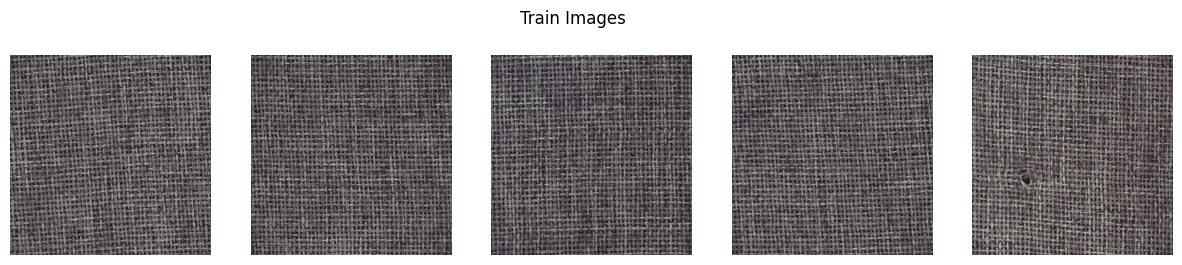

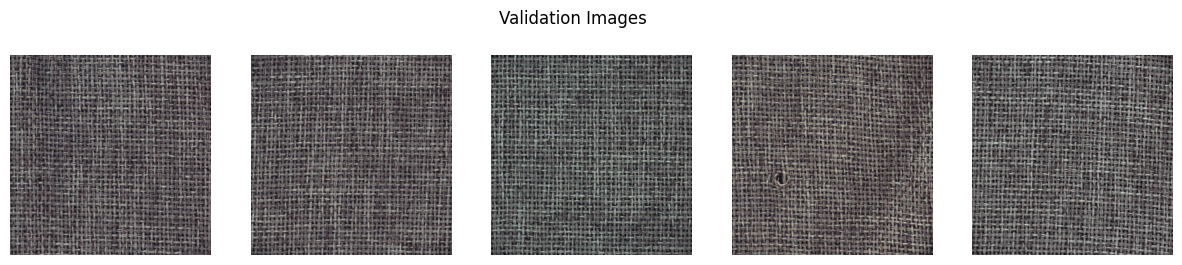

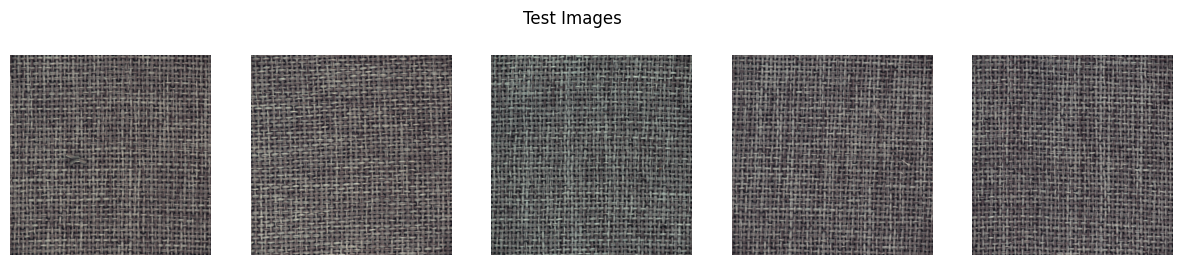

In [16]:
def show_images_from_df(df, title, n=5, image_column='image_path', grayscale=False):
    plt.figure(figsize=(15, 3))
    
    for i in range(min(n, len(df))):
        img_path = df.iloc[i][image_column]
        img = Image.open(img_path).convert("RGB")
        if grayscale:
            img = img.convert("L")  

        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray' if grayscale else None)
        plt.axis('off')

    plt.suptitle(title)
    plt.show()

# Usage
show_images_from_df(train_df, "Train Images")
show_images_from_df(val_df, "Validation Images")
show_images_from_df(test_df, "Test Images")